In [199]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler,Normalizer,OneHotEncoder,LabelEncoder,OrdinalEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge,LogisticRegression
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier,AdaBoostRegressor,GradientBoostingClassifier,GradientBoostingRegressor
from xgboost import XGBClassifier,XGBRegressor

from sklearn.metrics import root_mean_squared_error,mean_squared_error,mean_absolute_error,confusion_matrix,classification_report,accuracy_score,r2_score,recall_score,precision_score

In [200]:
df = pd.read_csv("/Users/prathamsharma/Desktop/Projects/LOAN PREDICTION/train_u6lujuX_CVtuZ9i (1).csv")

In [201]:
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [203]:
df.shape

(614, 13)

In [204]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [205]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [206]:
df = df.dropna()
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [207]:
df.shape

(480, 13)

In [208]:
le = LabelEncoder()
df["Loan_Status"] = le.fit_transform(df["Loan_Status"])

In [209]:
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [210]:
df["Property_Area"].unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [211]:
oe = OrdinalEncoder(categories=[["Rural","Semiurban","Urban"]])
oe.categories

[['Rural', 'Semiurban', 'Urban']]

In [212]:
df["Property_Area"] = oe.fit_transform(df[["Property_Area"]])
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,0.0,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,2.0,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,2.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,2.0,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,2.0,1
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,2.0,1
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,1.0,0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,2.0,1
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,1.0,0
10,LP001024,Male,Yes,2,Graduate,No,3200,700.0,70.0,360.0,1.0,2.0,1


In [213]:
le1 = LabelEncoder()
df["Self_Employed"] = le1.fit_transform(df["Self_Employed"])
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,0,4583,1508.0,128.0,360.0,1.0,0.0,0
2,LP001005,Male,Yes,0,Graduate,1,3000,0.0,66.0,360.0,1.0,2.0,1
3,LP001006,Male,Yes,0,Not Graduate,0,2583,2358.0,120.0,360.0,1.0,2.0,1
4,LP001008,Male,No,0,Graduate,0,6000,0.0,141.0,360.0,1.0,2.0,1
5,LP001011,Male,Yes,2,Graduate,1,5417,4196.0,267.0,360.0,1.0,2.0,1
6,LP001013,Male,Yes,0,Not Graduate,0,2333,1516.0,95.0,360.0,1.0,2.0,1
7,LP001014,Male,Yes,3+,Graduate,0,3036,2504.0,158.0,360.0,0.0,1.0,0
8,LP001018,Male,Yes,2,Graduate,0,4006,1526.0,168.0,360.0,1.0,2.0,1
9,LP001020,Male,Yes,1,Graduate,0,12841,10968.0,349.0,360.0,1.0,1.0,0
10,LP001024,Male,Yes,2,Graduate,0,3200,700.0,70.0,360.0,1.0,2.0,1


In [214]:
df["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [215]:
oe1 = OrdinalEncoder(categories=[["Not Graduate","Graduate"]])
oe1.categories

[['Not Graduate', 'Graduate']]

In [216]:
df["Education"] = oe1.fit_transform(df[["Education"]])
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,1.0,0,4583,1508.0,128.0,360.0,1.0,0.0,0
2,LP001005,Male,Yes,0,1.0,1,3000,0.0,66.0,360.0,1.0,2.0,1
3,LP001006,Male,Yes,0,0.0,0,2583,2358.0,120.0,360.0,1.0,2.0,1
4,LP001008,Male,No,0,1.0,0,6000,0.0,141.0,360.0,1.0,2.0,1
5,LP001011,Male,Yes,2,1.0,1,5417,4196.0,267.0,360.0,1.0,2.0,1
6,LP001013,Male,Yes,0,0.0,0,2333,1516.0,95.0,360.0,1.0,2.0,1
7,LP001014,Male,Yes,3+,1.0,0,3036,2504.0,158.0,360.0,0.0,1.0,0
8,LP001018,Male,Yes,2,1.0,0,4006,1526.0,168.0,360.0,1.0,2.0,1
9,LP001020,Male,Yes,1,1.0,0,12841,10968.0,349.0,360.0,1.0,1.0,0
10,LP001024,Male,Yes,2,1.0,0,3200,700.0,70.0,360.0,1.0,2.0,1


In [217]:
df["Dependents"].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [218]:
df["Dependents"]=df["Dependents"].replace(to_replace="3+",value="4")

In [219]:
df["Dependents"].unique()

array(['1', '0', '2', '4'], dtype=object)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a

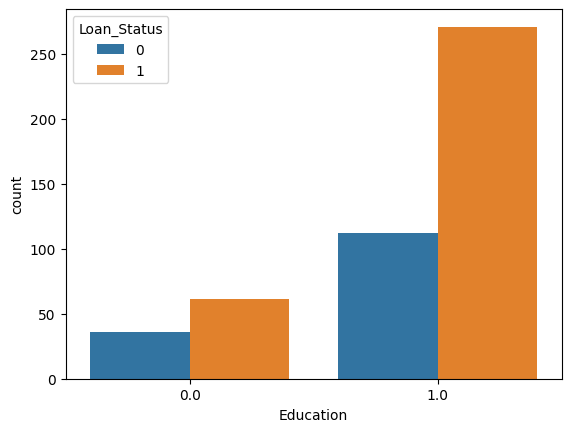

In [220]:
sns.countplot(x=df["Education"],hue=df["Loan_Status"])
plt.show()

In [221]:
le2 = LabelEncoder()
df["Gender"] = le2.fit_transform(df["Gender"])
print(le2.classes_)
df.head(10)

['Female' 'Male']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,Yes,1,1.0,0,4583,1508.0,128.0,360.0,1.0,0.0,0
2,LP001005,1,Yes,0,1.0,1,3000,0.0,66.0,360.0,1.0,2.0,1
3,LP001006,1,Yes,0,0.0,0,2583,2358.0,120.0,360.0,1.0,2.0,1
4,LP001008,1,No,0,1.0,0,6000,0.0,141.0,360.0,1.0,2.0,1
5,LP001011,1,Yes,2,1.0,1,5417,4196.0,267.0,360.0,1.0,2.0,1
6,LP001013,1,Yes,0,0.0,0,2333,1516.0,95.0,360.0,1.0,2.0,1
7,LP001014,1,Yes,4,1.0,0,3036,2504.0,158.0,360.0,0.0,1.0,0
8,LP001018,1,Yes,2,1.0,0,4006,1526.0,168.0,360.0,1.0,2.0,1
9,LP001020,1,Yes,1,1.0,0,12841,10968.0,349.0,360.0,1.0,1.0,0
10,LP001024,1,Yes,2,1.0,0,3200,700.0,70.0,360.0,1.0,2.0,1


In [222]:
le3 = LabelEncoder()
df["Married"] = le3.fit_transform(df["Married"])
print(le3.classes_)
df.head(10)

['No' 'Yes']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,1.0,0,4583,1508.0,128.0,360.0,1.0,0.0,0
2,LP001005,1,1,0,1.0,1,3000,0.0,66.0,360.0,1.0,2.0,1
3,LP001006,1,1,0,0.0,0,2583,2358.0,120.0,360.0,1.0,2.0,1
4,LP001008,1,0,0,1.0,0,6000,0.0,141.0,360.0,1.0,2.0,1
5,LP001011,1,1,2,1.0,1,5417,4196.0,267.0,360.0,1.0,2.0,1
6,LP001013,1,1,0,0.0,0,2333,1516.0,95.0,360.0,1.0,2.0,1
7,LP001014,1,1,4,1.0,0,3036,2504.0,158.0,360.0,0.0,1.0,0
8,LP001018,1,1,2,1.0,0,4006,1526.0,168.0,360.0,1.0,2.0,1
9,LP001020,1,1,1,1.0,0,12841,10968.0,349.0,360.0,1.0,1.0,0
10,LP001024,1,1,2,1.0,0,3200,700.0,70.0,360.0,1.0,2.0,1


SPLITTING THE DATA FOR MODEL TRAINING

In [223]:
x = df.drop(["Loan_ID","Loan_Status"],axis=1)
y=df["Loan_Status"]
print(x.shape,y.shape)

(480, 11) (480,)


In [224]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=2,stratify=y)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(432, 11) (48, 11) (432,) (48,)


In [225]:
svm = svm.SVC(kernel="linear")
svm.fit(x_train,y_train)

y_pred_train = svm.predict(x_train)
y_pred_test = svm.predict(x_test)

accuracy_training = accuracy_score(y_train,y_pred_train)
accuracy_testing = accuracy_score(y_test,y_pred_test)

print("ACCURACY SCORE FOR TRAINING DATA=",accuracy_training)
print("ACCURACY SCORE FOR TESTING DATA=",accuracy_testing)

ACCURACY SCORE FOR TRAINING DATA= 0.7893518518518519
ACCURACY SCORE FOR TESTING DATA= 0.8333333333333334
